# Simulaciones

Las ecuaciones de Lorenz fueron descubiertas por Edward Lorenz al tratar de entender el comportamiento impredecible del clima, para poder hacer esto tuvo que simplificar un modelo que representaba el clima, el cual contiene unas ecuaciones que están definidas por: [1]

$$
    \left\{\begin{array}{l}
\frac{dx}{dt}=\sigma(y-x) \\
\frac{dy}{dt}=x(\rho-z)-y \\
\frac{dz}{dt}=x y-\beta z 
\end{array}\right. 
$$

Donde $x$ representa la tasa de vuelco convectivo, $y$ la varianza horizontal de la temperatura y $z$ la varianza vertical de la temperatura, además, los valores de sigma, rho y beta son mayores que 0, normalmente se utilizan los parámetros de $\rho=28$, $\sigma=10$ y $\beta=8/3$ para poder observar el atractor; Lorenz aplicó integración numérica para así poder observar lo que harían las trayectorias formadas por dichas ecuaciones a lo largo del tiempo. [2]

Pero, para poder entender lo que representa el atractor de Lorenz, es necesario comprender algunos conceptos que describen su comportamiento, empezando por los atractores extraños, los cuales se refieren a regiones en el espacio que son invariantes a lo largo del tiempo, tienen una alta sensibilidad a las condiciones iniciales y atraen a la mayoría de trayectorias; estos también son los atractores que cuentan con una forma fractal, tal como la que tiene el atractor de Lorenz. [3] 

Luego tenemos a la bifurcación, dicho concepto se refiere al caso en el que se produzca un cambio cualitativo debido a una pequeña variación en los parámetros [4], este concepto se vuelve relevante con la bifurcación de Andronov-Hopf, la cual ocurre en el caso de estas ecuaciones ya que los puntos fijos siempre tendrán un eigenvalor negativo y un par de eigenvalores complejos, pero la parte real pasa de la parte real negativa a la parte real positiva en $\rho=\rho_{H}$. [2]

Fuera de estas dos bifurcaciones es importante mencionar a la bifurcación homoclínica, ya que cuando se tiene que $\rho = \rho' \approx 13.926$, se puede observar este tipo de bifurcación, debido a que la figura formada por las ecuaciones tiene dos trayectorias, una cuando $\rho$ es menor que $\rho'$, donde las dos trayectorias inestables son atraídas por los puntos fijos $C_1 = \left( \sqrt{\beta(\rho - 1)}, \sqrt{\beta(\rho - 1)}, \rho - 1 \right)$ y $C_2 = \left( -\sqrt{\beta(\rho - 1)}, -\sqrt{\beta(\rho - 1)}, \rho - 1 \right)$ y la otra cuando $\rho$ es mayor que $\rho'$, donde las órbitas siguen siento atraídas por los mismos puntos, pero su destino se ha intercambiado, es decir, las trayectorias de antes cambian su sentido, en este momento el sistema debe de pasar un estado inmediato donde se intercambian los dos puntos fijos, todo este fenómeno es parte de lo que le otorga su forma característica al atractor; para poder llegar a dicha forma, se debe de haber pasado la bifurcación de Andronov-Hopf, la cual ocurre cuando $\rho=\rho_{H} \approx 24.74$, ya que en este punto, tanto $C_1$ como $C_2$ se convierten en puntos fijos inestables y, cuando las órbitas se acercan al origen, empiezan a tener una trayectoria que se alterna entre los dos puntos, repitiendo este proceso hasta que se llegue a una cantidad establecida de tiempo, cada vez que se pasa por el origen se elige uno de los puntos dependiendo de la posición en que se hace el cruce, aquí es donde afectan las condiciones iniciales, ya que entre más se separan las órbitas, más diferentes serán sus elecciones del punto al cual acercarse. [2]

Estas ecuaciones son imposibles de resolver analíticamente, por lo cual se debe de ocupar una aproximación numérica.

## Método de Runge-Kutta de cuarto orden

Los métodos iterativos de Runge-Kutta son ocupados para aproximar soluciones a ecuaciones diferenciales ordinarias, de estos métodos, el de cuarto orden es uno de los más utilizados, debido a su balance óptimo entre el costo computacional y la precisión de este.

Para poder ocupar dicho método se debe contar con una ecuación diferencial ordinaria de la forma:

$$
\frac{dy(t)}{dt} = f(y(t),t)
$$

Con una condición inicial de: [5]
$$
y(t_0)=y_0
$$

En este caso, las ecuaciones de Lorenz representan una ecuacion diferencial ordinaria para la cual se debe de obtener una respuesta aproximada, debido a esto la ecuación que se ocupará para resolver estas ecuaciones numéricamente es la siguiente: [6]

$$
\begin{aligned}
w_{0} & =\alpha \\
k_{1} & =h f\left(t_{i}, w_{i}\right) \\
k_{2} & =h f\left(t_{i}+\frac{h}{2}, w_{i}+\frac{1}{2} k_{1}\right) \\
k_{3} & =h f\left(t_{i}+\frac{h}{2}, w_{i}+\frac{1}{2} k_{2}\right) \\
k_{4} & =h f\left(t_{i+1}, w_{i}+k_{3}\right) \\
w_{i+1} & =w_{i}+\frac{h}{6}\left(k_{1}+2 k_{2}+2 k_{3}+k_{4}\right)
\end{aligned}
$$

Donde $h$ es el paso de tiempo y $\alpha$ es el valor de $y$ en la condición inicial ($t_0$), luego se obtiene un valor para la pendiente en distintos puntos, en este caso: $k_1$ es la pendiente al inicio del paso, luego $k_2$ es la pendiente en el punto medio, cuyo valor es más preciso que $k_1$ al hacer nuevas aproximaciones para $y(t)$, después se realiza el proceso de la misma manera, pero ahora con $k_3$ y $k_2$, y finalmente con $k_4$ para completar el paso de tiempo; a partir de este proceso se obtien $w_{i+1}$, el cual es el último estimado en base a los valores anteriores y será el valor ocupado para la siguiente iteración. [5]

Cabe resaltar que este método cuenta con un error local de truncamiento de $O(h^4)$ siempre que su solución, es decir, $y(t)$, cuente con cinco derivadas continuas [6], además, al ser un método de cuarto orden, se tendrá un menor error comparado al método de Euler, una prueba sencilla de este dato se puede encontrar con la siguiente ecuación diferencial:

$$
\frac {dy}{dt} = -2ty^2, \ y(0)=1
$$

La cual tiene como solución al problema de valor inicial la ecuación $y(t)=1/(1+t^2)$, si se utiliza el método de Runge-Kutta de cuarto orden, con $t$ en un intervalo de $[0,2]$ y haciendo uso de diez pasos, se obtiene que el error con esta aproximación es de $1.095\times10^{-5}$, si se ocupan veinte pasos entonces se obtiene un error de $6.541\times10^{-7}$, si se dividen estos dos valores se puede observar una relación de 16.75, esto indica que, al duplicar la cantidad de pasos, el error mejora por un factor de 16, siendo este número un equivalente de $2^4$, este es un comportamiento esperado de un método que cuenta con un orden 4. [4]

## Implementación en código del Método de Runge-Kutta

Definiendo el Runge-Kutta:

In [1]:
import numpy as np
from matplotlib import pyplot as plt

def runge_kutta_4(f, dt, t0, y0):
    f1 = f(t0, y0)
    f2 = f(t0 + dt / 2, y0 + (dt / 2) * f1)
    f3 = f(t0 + dt / 2, y0 + (dt / 2) * f2)
    f4 = f(t0 + dt, y0 + dt * f3)
    y_out = y0 + (dt / 6) * (f1 + 2 * f2 + 2 * f3 + f4)
    return y_out

Definiendo el sistema de Lorenz:

In [2]:
def lorenz(sigma, beta, rho, y):
    # En el vector "y" se guardan los datos de (x(0),y(0),z(0))
    dy = [sigma * (y[1] - y[0]), 
          y[0] * (rho - y[2]) - y[1],
          y[0] * y[1] - beta * y[2]]
    return np.array(dy)

Definiendo una función para simular el atractor de Lorenz:

In [3]:
def atractor(dt, T, sigma, beta, rho, y0):
    # Consiguiendo la trayectoria
    n_pasos = int(T / dt) 
    t = np.linspace(0, T, n_pasos) # Esta operación consigue un vector de tiempo para poder ocupar los datos de dt y T a la hora de graficar
    
    Y = np.zeros((3, n_pasos))
    Y[:, 0] = y0 # Inicializando la primera columna con la condición inicial
    y_inicial = y0
    for i in range(n_pasos - 1):
        f = lambda t, y: lorenz(sigma, beta, rho, y)
        y_final = runge_kutta_4(f, dt, t[i], y_inicial)
        Y[:, i + 1] = y_final
        y_inicial = y_final
    
    ax = plt.figure().add_subplot(projection='3d')
    ax.plot(Y[0, :], Y[1, :], Y[2, :], lw=0.5)
    
    plt.show()

Primer caso:

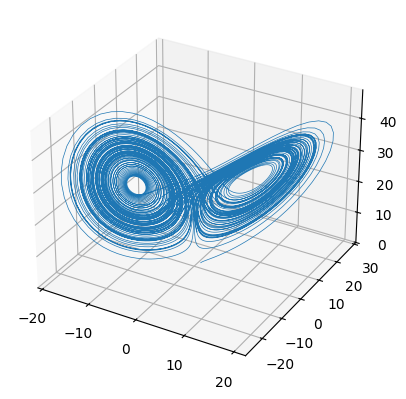

In [4]:
# Condiciones para el atractor de Lorenz:
sigma = 10
beta = (8 / 3)
rho = 28

# Condiciones iniciales (x(0),y(0),z(0))
condiciones_iniciales = [1, 1, 1]

# Paso y tiempo final
dt=0.01
T=100

# Generando un atractor con las condiciones mencionadas anteriormente:
atractor(dt, T, sigma, beta, rho, condiciones_iniciales)

Segundo caso:

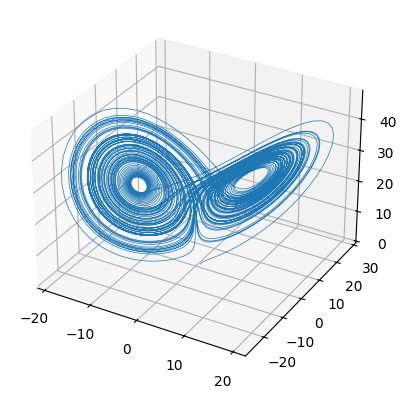

In [5]:
# Condiciones para el atractor de Lorenz:
sigma = 10
beta = (8 / 3)
rho = 28

# Condiciones iniciales (x(0),y(0),z(0))
condiciones_iniciales = [1.002025, 0.2, 0.4]

# Paso y tiempo final
dt=0.01
T=100

# Generando un atractor con las condiciones mencionadas anteriormente:
atractor(dt, T, sigma, beta, rho, condiciones_iniciales)

Tercer caso:

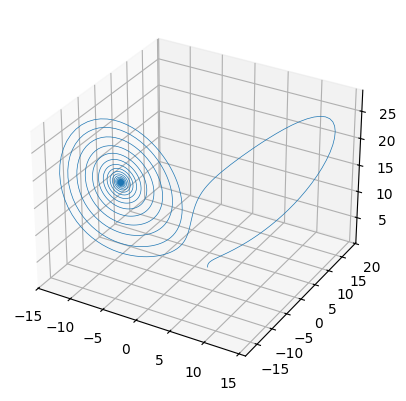

In [6]:
# Condiciones para el atractor de Lorenz:
sigma = 9
beta = (10 / 3)
rho = 18

# Condiciones iniciales (x(0),y(0),z(0))
condiciones_iniciales = [2, 0.009, 0.7]

# Paso y tiempo final
dt=0.01
T=100

# Generando un atractor con las condiciones mencionadas anteriormente:
atractor(dt, T, sigma, beta, rho, condiciones_iniciales)

Para poder observar como cambia el sistema debido a sus condiciones iniciales, se pueden graficar las variables de x, y, z a lo largo del tiempo, ocupando la siguiente función:

In [7]:
def graficas_variables(caso, y0, sigma, beta, rho, dt, T):   

    n_pasos = int(T / dt)
    t = np.linspace(0, T, n_pasos) # Esta operación consigue un vector de tiempo para poder ocupar los datos de dt y T a la hora de graficar

    Y = np.zeros((3, n_pasos))
    Y[:, 0] = y0 # Inicializando la primera columna con la condición inicial
    y_inicial = y0
    for i in range(n_pasos - 1):
        f = lambda t, y: lorenz(sigma, beta, rho, y)
        y_final = runge_kutta_4(f, dt, t[i], y_inicial)
        Y[:, i + 1] = y_final
        y_inicial = y_final

    # Graficando las variables en función del tiempo
    fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
    fig.suptitle(caso, y=0.925, fontsize=16)

    axs[0].plot(t, Y[0, :], label='x(t)')
    axs[0].legend()
    axs[1].plot(t, Y[1, :], label='y(t)', color='teal')
    axs[1].legend()
    axs[2].plot(t, Y[2, :], label='z(t)', color='steelblue')
    axs[2].legend()

    plt.show()

Ahora para el primer caso:

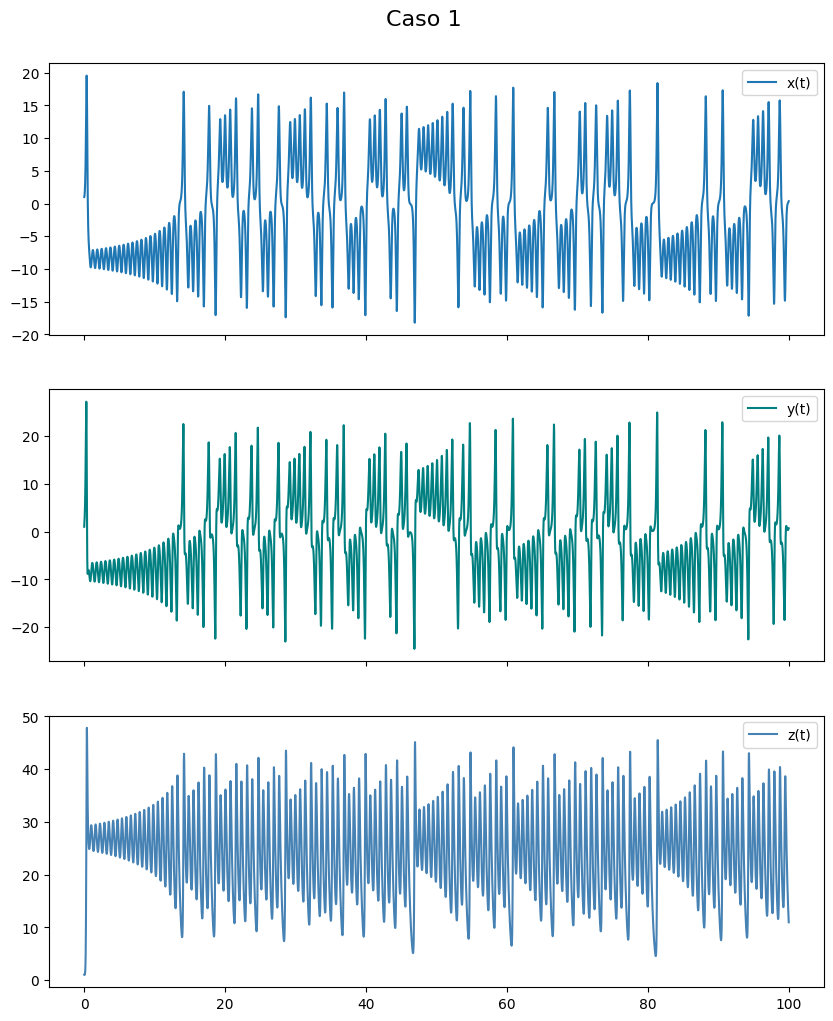

In [8]:
# Condiciones para el atractor de Lorenz:
sigma = 10
beta = (8 / 3)
rho = 28

# Condiciones iniciales (x(0),y(0),z(0))
y0 = [1, 1, 1]

# Paso y tiempo final
dt=0.01
T=100

# Generando un atractor con las condiciones mencionadas anteriormente:
graficas_variables('Caso 1', y0, sigma, beta, rho, dt, T)

Para el segundo caso:

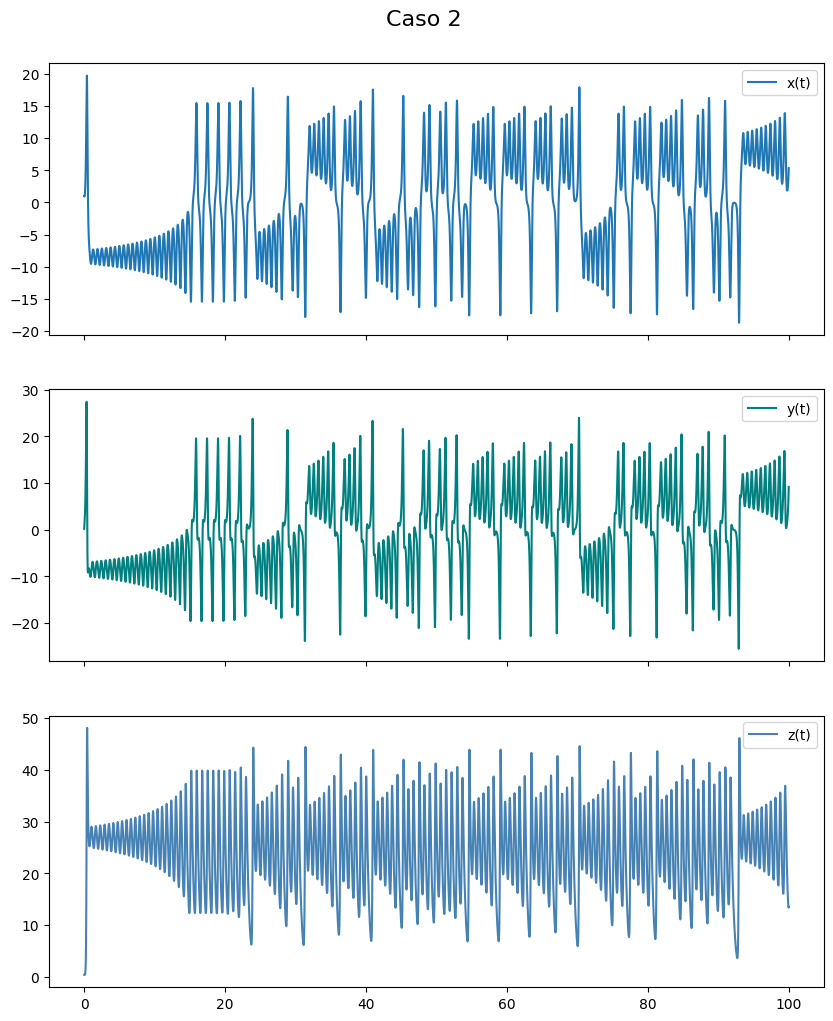

In [9]:
# Condiciones para el atractor de Lorenz:
sigma = 10
beta = (8 / 3)
rho = 28

# Condiciones iniciales (x(0),y(0),z(0))
y0 = [1.002025, 0.2, 0.4]

# Paso y tiempo final
dt=0.01
T=100

# Generando un atractor con las condiciones mencionadas anteriormente:
graficas_variables('Caso 2', y0, sigma, beta, rho, dt, T)

Y para el tercer caso:

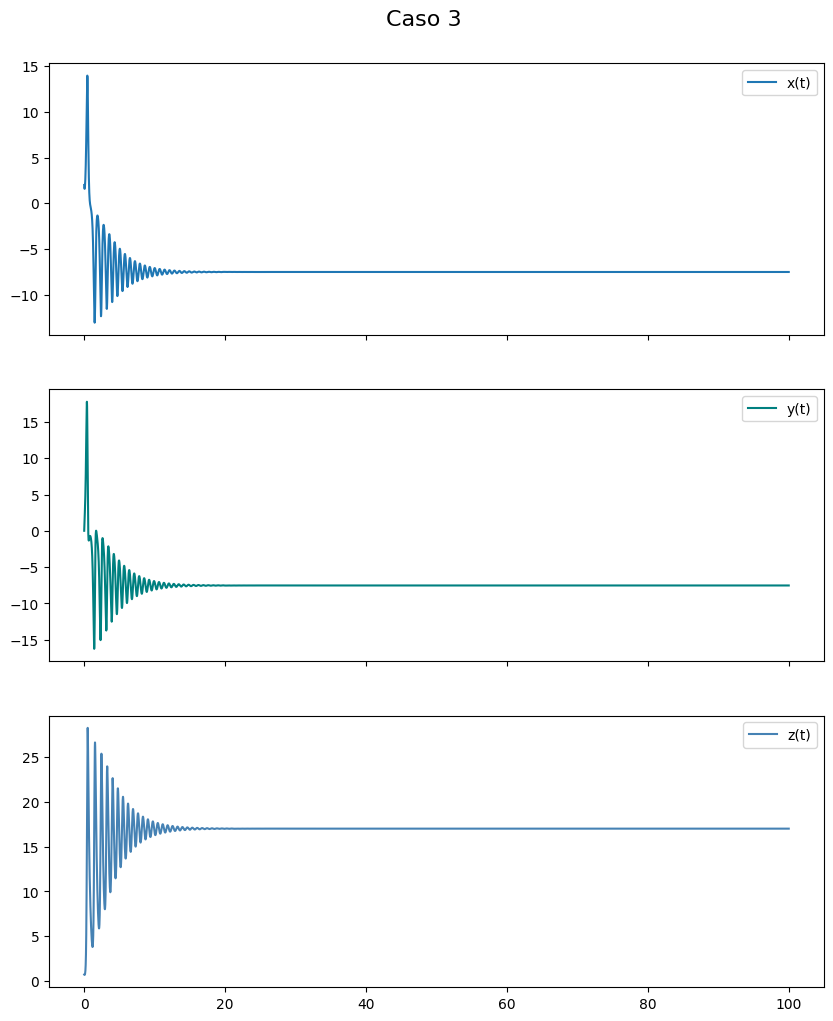

In [10]:
# Condiciones para el atractor de Lorenz:
sigma = 9
beta = (10 / 3)
rho = 18

# Condiciones iniciales (x(0),y(0),z(0))
y0 = [2, 0.009, 0.7]

# Paso y tiempo final
dt=0.01
T=100

# Generando un atractor con las condiciones mencionadas anteriormente:
graficas_variables('Caso 3', y0, sigma, beta, rho, dt, T)

### Variación de los parámetros
Ahora bien, la trayectoria del atractor no es periódica y el comportamiento de este es afectado de una gran manera dependiendo de sus parámetros, lo que lo hace un sistema altamente caótico, esto es debido a que cualquier cambio en estos, sin importar que tan mínimo sea, creará un atractor distinto, además, cada parámetro tiene un rol distinto a la hora de generar un atractor, por ejemplo:

- **Sigma**: Es proporcional al número de Prandtl, esto es debido al fenómeno que dió origen a las ecuaciones de Lorenz, y es el encargado de controlar a $x$ respecto a su diferencia con $y$, entre más grande sea dicho parámetro, mayor será la inestabilidad del sistema.
  
- **Rho**: Valor proporcional al número de Rayleigh, si este es menor que 1 entonces su único punto fijo será estable y en el origen, si es mayor a 1 se crea una bifurcación tridente debido a que aparecen dos puntos puntos fijos además del original. Pero para poder observar el atractor de Lorenz, este debe de ser mayor o igual que 24.74, ya que este es el punto de la bifurcación de Andronov-Hopf y desde este punto se crea el comportamiento caótico característico. 

- **Beta**: Este valor afecta a la disipación en $z$, si se cambia entonces se modificará la forma de las órbitas. [2]

### Dinámica del sistema
Al observar las gráficas podemos encontrar que, en los primeros dos casos, las trayectorias son iguales en un principio, pero rápidamente cambian y luego cada variable cuenta con cierta oscilación, por lo que ya no vuelven a ser similares, aunque en el caso 3 es distinto, ya que este no tiene una forma caótica así como los demás casos, debido a que sus variables se mantienen estables y no siguen oscilando, lo cual es debido al valor de rho que se ha ocupado en este caso, ya que, al ser menor que 24.74, la figura no se convertirá en un atractor, aunque sí tendrá una bifurcación; gracias a esto se puede establecer que cualquier diferencia en las condiciones iniciales del atractor llevaran a un comportamiento completamente diferente, cambiando así qué parte de este es la que será observada primero, aunque la forma del propio atractor no cambie si no cambian los parámetros de este [2], esto se encuentra justificado por las órbitas homoclínicas mencionadas anteriormente en la definición de las ecuaciones de Lorenz.


### Referencias bibliograficas

[1] E. N. Lorenz, “Deterministic nonperiodic flow,” Journal of Atmospheric Sciences, vol. 20, no. 2, pp. 130 – 141, 1963.

[2] K. Zhang, “The lorenz system – An introduction to chaos” 2022.

[3] J. Hateley, “The lorenz system,” Lecture Notes, http://web.math.ucsb.edu/jhate-ley/paper/lorenz.pdf, 2019

[4] PP. Blanchard, R. Devaney, and G. Hall, Differential Equations. Estados Unidos: Cengage Learning, cuarta ed., 2011.

[5] E. Cheever, “Fourth order runge-kutta”.

[6] R. Burden and J. D. Faires, Numerical Analysis. International Thomson, 9th ed., 2011.